In [1]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()

In [28]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from concurrent.futures import ProcessPoolExecutor

#file = "/gv0/Users/achihwan/SKNano/Run3NanoAODv13p1/2022/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV_0.root"
#file = "/gv0/Users/youngwan_public/WRTauNano/WRtoNTautoTauTauJJ_WR2000_N1000_TuneCP5_13TeV_madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2520000/1FEF32A9-D5E4-1945-A424-46E0AE558EDC.root" # tau
file = "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2100_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2100_13p6TeV_2.root"
access_log = []
events = NanoEventsFactory.from_root(
    {file: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log,
).events()

file2 =  "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV_1.root"
access_log2 = []
events2 = NanoEventsFactory.from_root(
    {file2: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log2,
).events()
file3 = "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2900_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2900_13p6TeV_2.root"
access_log3 = []
events3 = NanoEventsFactory.from_root(
    {file3: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log3,
).events()

[548, 926, 485, 683, 605, 450, 1.08e+03, ..., 447, 1.04e+03, 242, 563, 851, 415]
[694, 288, 294, 684, 573, 381, 731, 462, ..., 705, 821, 493, 769, 614, 481, 651]


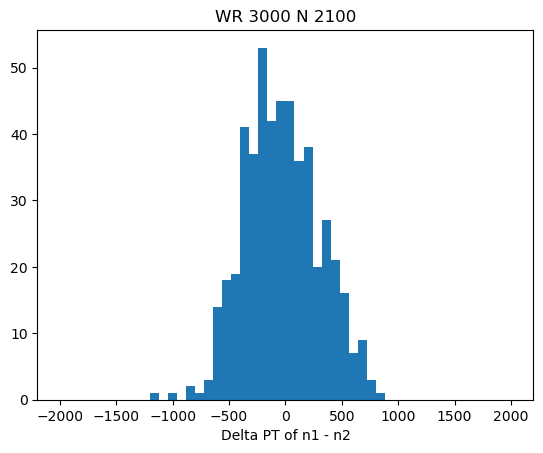

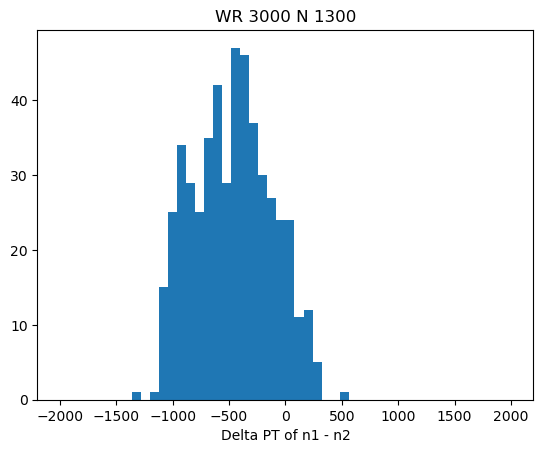

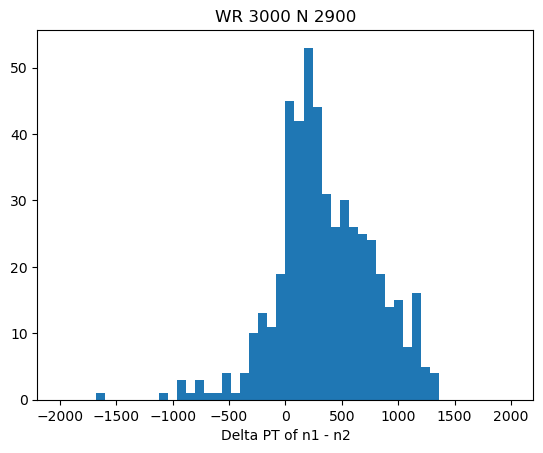

In [29]:
n1 = events.LHEPart.pt[:,3]
n2 = events.LHEPart.pt[:,-1]
print(n1)
print(n2)
deltapt = n1 - n2
plt.hist(deltapt, bins=50, range=(-2000,2000))
plt.xlabel("Delta PT of n1 - n2")
plt.title("WR 3000 N 2100")
plt.show()

n1 = events2.LHEPart.pt[:,3]
n2 = events2.LHEPart.pt[:,-1]
deltapt = n1 - n2
plt.hist(deltapt, bins=50, range=(-2000,2000))
plt.xlabel("Delta PT of n1 - n2")
plt.title("WR 3000 N 1300")
plt.show()

n1 = events3.LHEPart.pt[:,3]
n2 = events3.LHEPart.pt[:,-1]
deltapt = n1 - n2
plt.hist(deltapt, bins=50, range=(-2000,2000))
plt.xlabel("Delta PT of n1 - n2")
plt.title("WR 3000 N 2900")
plt.show()



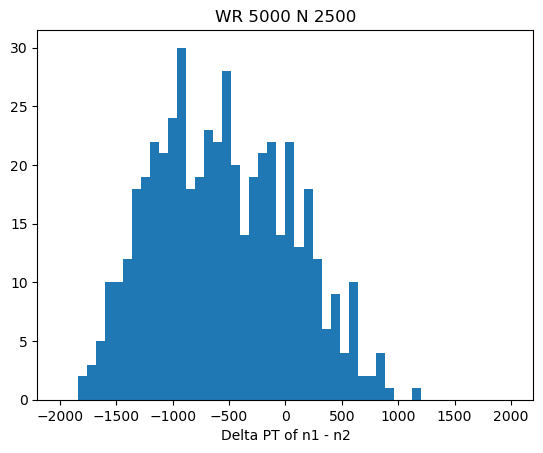

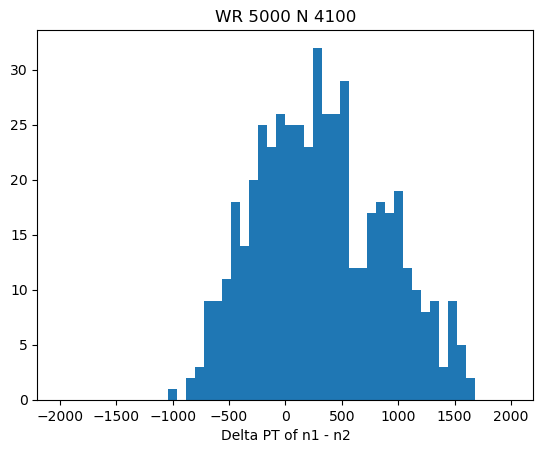

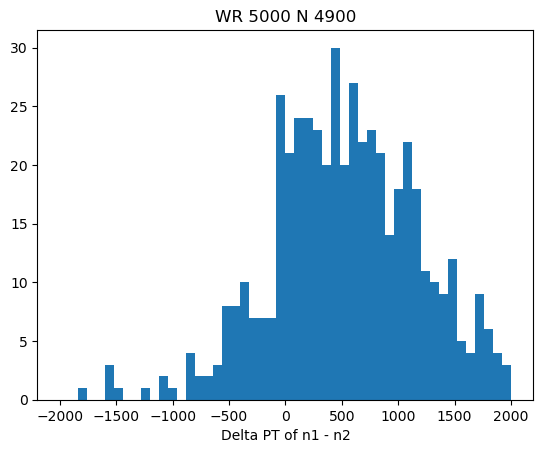

In [31]:
file4  = "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-5000_MN-2500_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-5000_MN-2500_13p6TeV_3.root"
access_log4 = []
events4 = NanoEventsFactory.from_root(
    {file4: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log4,
).events()  

n1 = events4.LHEPart.pt[:,3]
n2 = events4.LHEPart.pt[:,-1]
deltapt = n1 - n2
plt.hist(deltapt, bins=50, range=(-2000,2000))
plt.xlabel("Delta PT of n1 - n2")
plt.title("WR 5000 N 2500")
plt.show()

file5 = "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-5000_MN-4100_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-5000_MN-4100_13p6TeV_3.root"
access_log5 = []
events5 = NanoEventsFactory.from_root(
    {file5: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log5,
).events()

n1 = events5.LHEPart.pt[:,3]
n2 = events5.LHEPart.pt[:,-1]
deltapt = n1 - n2
plt.hist(deltapt, bins=50, range=(-2000,2000))
plt.xlabel("Delta PT of n1 - n2")
plt.title("WR 5000 N 4100")
plt.show()

file6 =  "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-5000_MN-4900_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-5000_MN-4900_13p6TeV_8.root"
access_log6 = []
events6 = NanoEventsFactory.from_root(
    {file6: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log6,
).events()  
n1 = events6.LHEPart.pt[:,3]
n2 = events6.LHEPart.pt[:,-1]
deltapt = n1 - n2
plt.hist(deltapt, bins=50, range=(-2000,2000))
plt.xlabel("Delta PT of n1 - n2")
plt.title("WR 5000 N 4900")
plt.show()

### 결론 : Tight lepton (global high pt muon + trkiso , heep id )로 먼저 고르고 Loose lepton으로 fatjet 안에 있는거 골라서 리딩이 팻젯 안으로 들어갈 걱정은 안 해도 될거 같음 . 

## Fatjet 밖으로 렙톤 나가버리는지 확인 

In [ ]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from concurrent.futures import ProcessPoolExecutor

#file = "/gv0/Users/achihwan/SKNano/Run3NanoAODv13p1/2022/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV_0.root"
#file = "/gv0/Users/achihwan/SKNano/Run3NanoAODv13p1/2022/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2900_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2900_13p6TeV_2.root"
#file = "/gv0/Users/youngwan_public/WRTauNano/WRtoNTautoTauTauJJ_WR2000_N1000_TuneCP5_13TeV_madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2520000/1FEF32A9-D5E4-1945-A424-46E0AE558EDC.root" # tau
file = "/gv0/Users/youngwan_public/WRTauNano/WRtoNTautoTauTauJJ_WR2000_N100_TuneCP5_13TeV_madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2520000/04481D0F-7CE7-6341-9091-742B6675FC7E.root"
#file = "/data6/Users/achihwan/LRSM_tb_channel/SAMPLEPRODUCTION/samples/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2100_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-2100_13p6TeV_2.root"
#file = "/gv0/Users/youngwan_public/WRTauNano/WRtoNTautoTauTauJJ_WR2000_N100_TuneCP5_13TeV_madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2520000/04481D0F-7CE7-6341-9091-742B6675FC7E.root"
access_log = []
events = NanoEventsFactory.from_root(
    {file: "Events"},
    schemaclass = NanoAODSchema,
    mode="eager",
    access_log=access_log,
).events()

[2, 1, 2, 1, 0, 0, 0, 2, 1, 0, 0, 0, 0, ..., 2, 1, 3, 3, 1, 0, 1, 1, 2, 0, 2, 3]
[False, False, False, False, True, True, ..., False, False, True, False, False]
500
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
130
------ LHE Particles ------
[[4, -3, 24, 13, 4, -3, 5, -5, -13], ..., [2, -1, 24, 13, ..., -3, 5, -5, -13]]
[[13, -13], [-13, -13], [13, 13], [...], ..., [-13, -13], [-13, -13], [13, -13]]
130
Events after filtering None: 130
Chosen FatJet count: 130
[3.53, 0.0568, 3.26, 3.06, 3.16, 3.11, ..., 3.69, 3.7, 3.98, 2.75, 2.94, 3.17]
[0.171, 2.82, 0.211, 0.207, 3.15, 2.08, ..., 3.05, 0.156, 0.277, 2.22, 2.44]


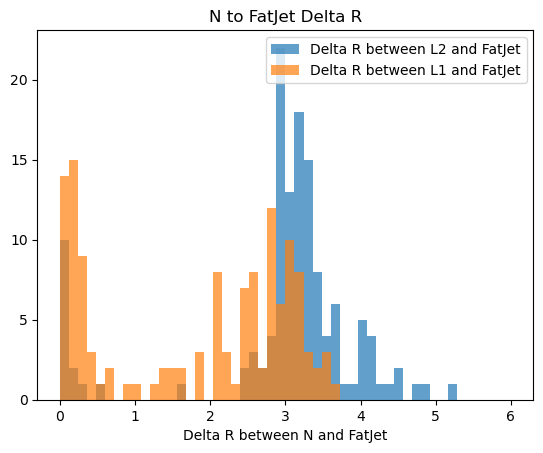

In [41]:
import numpy as np
import matplotlib.pyplot as plt
lhe = events.LHEPart
lheid = events.LHEPart.pdgId
ak8 = events.FatJet

sdm = events.FatJet.msoftdrop
max_indices_sdm = np.argmax(sdm, axis=1)

ak8pt = events.FatJet.pt
max_indices_pt = np.argmax(ak8pt, axis=1)

max_same_index = max_indices_sdm == max_indices_pt
N_cand = max_indices_sdm[max_same_index] #  이벤트 중 N이 매칭되는거의 팻젯의 인덱스 
print(max_indices_sdm)
print(max_same_index)
print(len(max_same_index))
print(N_cand)
print(len(N_cand))

print("------ LHE Particles ------")
print(lheid)
muon = abs(lheid)==13
print(lheid[muon])
l1 = lhe[muon][:,0]
l2 = lhe[muon][:,1]

using_l1 = l1[max_same_index]
using_l2 = l2[max_same_index]
print(len(using_l1))

# l2 와 팻젯의 델타 r 계산
using_ak8 = ak8[max_same_index] ## 매치되는 이벤트 고름 
# 각 이벤트에서 사용하는 인덱스 
# 각 event에서 N_cand 번째 FatJet을 선택
chosen_ak8_list = []
valid_mask = ~ak.is_none(N_cand)

# 2. 모든 물리 객체(Muon, FatJet, Index)에 동일한 마스크 적용 (길이를 맞춤)
# 여기서 l1, l2도 2285개로 줄어들어 FatJet과 개수가 같아집니다.
final_l1 = using_l1[valid_mask]
final_l2 = using_l2[valid_mask]
final_ak8 = using_ak8[valid_mask]
final_indices = N_cand[valid_mask]

print(f"Events after filtering None: {len(final_l1)}")  # 2285로 동일해야 함

# 3. FatJet 선택 (Loop 없이 한 번에 선택)
# final_ak8에서 각 이벤트별로 final_indices 번째 젯을 선택
# Awkward Array의 고급 인덱싱 사용: array[range(len), indices]
# ---------------------------------------------------------
# 3. FatJet 선택 (Loop 없이 한 번에 선택 - 수정됨)
# ---------------------------------------------------------

# [중요] ak.num(...) > ... 은 마스크일 뿐, 젯을 선택해주지 않습니다.
# 반드시 아래처럼 numpy arange를 이용해 '콕 집어서' 선택해야 합니다.
# 구조: array[ <이벤트 번호들>, <각 이벤트의 젯 인덱스들> ]
# ---------------------------------------------------------
## ---------------------------------------------------------
# 3. FatJet 선택 (Awkward 정석 방법: Unflatten -> Slice -> Flatten)
# ---------------------------------------------------------
# 원리:
# 1. 인덱스를 [[1], [0], ...] 처럼 이벤트당 하나씩 들어있는 리스트(Jagged)로 만듭니다.
# 2. 이 인덱스로 팻젯을 자르면, 이벤트당 팻젯이 딱 1개씩만 남습니다.
# 3. 마지막으로 리스트 껍질을 벗겨(flatten) 평평한 배열로 만듭니다.

# (1) 인덱스를 Jagged Array 형태로 변환 (counts=1)
indices_jagged = ak.unflatten(final_indices, 1)

# (2) 슬라이싱 (각 이벤트 리스트에서 해당 인덱스에 있는 젯만 선택)
selected_jagged = final_ak8[indices_jagged]

# (3) 껍질 벗기기 (이벤트당 1개뿐이므로 axis=1로 flatten 하면 됨)
chosen_ak8 = ak.flatten(selected_jagged, axis=1)

# ---------------------------------------------------------
# 확인 및 계산
# ---------------------------------------------------------
print(f"Chosen FatJet count: {len(chosen_ak8)}") # 2285 확인

# Delta R 계산
delta_r_l2_ak8 = final_l2.delta_r(chosen_ak8)
delta_r_l1_ak8 = final_l1.delta_r(chosen_ak8)


print(delta_r_l2_ak8)
print(delta_r_l1_ak8)

plt.hist(delta_r_l2_ak8, bins=50, range=(0,6), alpha=0.7, label='Delta R between L2 and FatJet')
plt.hist(delta_r_l1_ak8, bins=50, range=(0,6), alpha=0.7, label='Delta R between L1 and FatJet')
plt.xlabel("Delta R between N and FatJet")
plt.title("N to FatJet Delta R")
plt.legend()
plt.show()



In [42]:
import plotly.graph_objects as go
import numpy as np
import awkward as ak

# --- CMS Geometry Constants (가상의 비율) ---
R_BARREL = 1.0  # 배럴 반지름
Z_MAX = 3.0     # 엔드캡 위치 (z축)

# --- Helper: Eta/Phi 방향으로 벽까지의 거리 계산 ---
def get_distance_to_wall(eta, phi):
    """
    원점에서 출발하여 eta, phi 방향으로 날아갔을 때
    배럴(R=1) 또는 엔드캡(Z=3)에 닿는 거리를 반환
    """
    eta_safe = np.clip(float(eta), -10, 10)
    theta = 2 * np.arctan(np.exp(-eta_safe))
    
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    
    # 배럴(원통 옆면)까지의 거리: r / sin(theta)
    # sin_theta가 0에 가까우면(빔 파이프 방향) 무한대 처리
    dist_r = abs(R_BARREL / sin_theta) if abs(sin_theta) > 1e-6 else 9999
    
    # 엔드캡(원통 뚜껑)까지의 거리: z / cos(theta)
    dist_z = abs(Z_MAX / cos_theta) if abs(cos_theta) > 1e-6 else 9999
    
    # 둘 중 더 짧은 거리가 실제 부딪히는 지점
    return min(dist_r, dist_z)

# --- Helper: 3D Unit Vector ---
def get_unit_vector(eta, phi):
    theta = 2 * np.arctan(np.exp(-float(eta)))
    vx = np.sin(theta) * np.cos(float(phi))
    vy = np.sin(theta) * np.sin(float(phi))
    vz = np.cos(theta)
    return np.array([vx, vy, vz])

# --- Helper: Ideal Cone Mesh ---
def get_ideal_jet_cone_mesh(jet_data, delta_r=0.8, n_points=60):
    j_eta = float(jet_data['eta'])
    j_phi = float(jet_data['phi'])
    
    # *** 핵심 수정: 길이를 고정하지 않고 벽까지의 거리로 설정 ***
    length = get_distance_to_wall(j_eta, j_phi)

    # 1. Jet 중심축 벡터
    J = get_unit_vector(j_eta, j_phi)

    # 2. 수직 벡터 찾기 (좌표계 회전용)
    if abs(J[2]) < 0.9: K = np.array([0, 0, 1])
    else: K = np.array([0, 1, 0])
    
    u = np.cross(J, K)
    u = u / np.linalg.norm(u)
    v = np.cross(J, u)

    # 3. 원뿔 밑면 생성
    # delta_r을 각도로 사용하여 밑면 반지름 계산
    base_radius = length * np.tan(delta_r) 
    base_center = length * J

    alphas = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    
    x_verts = [0.0] # Apex
    y_verts = [0.0]
    z_verts = [0.0]
    
    # 밑면 점들
    for alpha in alphas:
        p = base_center + base_radius * (np.cos(alpha) * u + np.sin(alpha) * v)
        x_verts.append(p[0])
        y_verts.append(p[1])
        z_verts.append(p[2])

    # 면(Face) 인덱스
    i_idx, j_idx, k_idx = [], [], []
    for k in range(n_points):
        i_idx.append(0)
        j_idx.append(k + 1)
        k_idx.append((k + 1) % n_points + 1)

    return x_verts, y_verts, z_verts, i_idx, j_idx, k_idx

# --- Main Plotting Function ---
def plot_event_display_final(l1, l2, jets, event_idx=0):
    if len(l1) <= event_idx:
        print(f"Error: Event index {event_idx} is out of range.")
        return

    # 데이터 추출 함수
    def get_data(p, i):
        return {'pt': p[i].pt, 'eta': p[i].eta, 'phi': p[i].phi}

    p_l1 = get_data(l1, event_idx)
    p_l2 = get_data(l2, event_idx)
    p_jet = get_data(jets, event_idx)

    fig = go.Figure()

    # 1. Detector Barrel (참조용 와이어프레임)
    # 벽 위치를 명확히 보여주기 위해 opacity를 약간 높임
    theta_grid = np.linspace(0, 2*np.pi, 40)
    z_grid = np.linspace(-Z_MAX, Z_MAX, 10)
    th_mesh, z_mesh = np.meshgrid(theta_grid, z_grid)
    x_cyl = R_BARREL * np.cos(th_mesh)
    y_cyl = R_BARREL * np.sin(th_mesh)
    
    fig.add_trace(go.Surface(
        x=x_cyl, y=y_cyl, z=z_mesh,
        opacity=0.15, showscale=False, colorscale='Gray', 
        name='Barrel Wall', hoverinfo='skip'
    ))

    # 2. Muon Tracks (벽까지만 그리기)
    def add_track(p_data, name, color):
        # 벽까지의 거리 계산
        d = get_distance_to_wall(p_data['eta'], p_data['phi'])
        # 방향 벡터
        uv = get_unit_vector(p_data['eta'], p_data['phi'])
        end_pt = uv * d
        
        hover = f"{name}<br>Pt: {p_data['pt']:.1f}<br>Eta: {p_data['eta']:.2f}<br>Phi: {p_data['phi']:.2f}"
        fig.add_trace(go.Scatter3d(
            x=[0, end_pt[0]], y=[0, end_pt[1]], z=[0, end_pt[2]],
            mode='lines', line=dict(color=color, width=4),
            name=name, hoverinfo='text', text=hover
        ))

    add_track(p_l1, "Muon 1", "red")
    add_track(p_l2, "Muon 2", "red")

    # 3. FatJet Cone (벽에 딱 맞춰 그리기)
    # Cone Mesh 생성 (길이 자동 계산됨)
    xv, yv, zv, ii, jj, kk = get_ideal_jet_cone_mesh(p_jet, delta_r=0.8)
    
    # Cone Mesh
    fig.add_trace(go.Mesh3d(
        x=xv, y=yv, z=zv, i=ii, j=jj, k=kk,
        opacity=0.4, color='blue', name='FatJet Cone', hoverinfo='name',
        flatshading=True
    ))
    
    # Jet Axis (중심축)
    d_jet = get_distance_to_wall(p_jet['eta'], p_jet['phi'])
    uv_jet = get_unit_vector(p_jet['eta'], p_jet['phi'])
    end_jet = uv_jet * d_jet
    
    jet_hover = f"FatJet Axis<br>Pt: {p_jet['pt']:.1f}<br>Eta: {p_jet['eta']:.2f}"
    fig.add_trace(go.Scatter3d(
        x=[0, end_jet[0]], y=[0, end_jet[1]], z=[0, end_jet[2]],
        mode='lines', line=dict(color='cyan', width=5),
        name='Jet Axis', hoverinfo='text', text=jet_hover
    ))

    # 4. Layout
    limit = 3.5 # 축 범위
    fig.update_layout(
        title=f"Event Display (Bounded to Detector) - Event #{event_idx}",
        scene=dict(
            xaxis=dict(range=[-limit, limit], showgrid=False, visible=False),
            yaxis=dict(range=[-limit, limit], showgrid=False, visible=False),
            zaxis=dict(range=[-4, 4], showgrid=False, title="Beam Line"),
            aspectmode='data',
            camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))
        ),
        template="plotly_dark",
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

# --- 실행 ---
plot_event_display_final(using_l1[deltar_over2], using_l2[deltar_over2], chosen_ak8[deltar_over2], event_idx=1)
print(delta_r_l2_ak8[deltar_over2][1])
print(delta_r_l1_ak8[deltar_over2_1][1])

3.2641838
3.1528141


In [ ]:
a=1
print(a)


1
